# FraudGuard 🛡️

## Sistema de Detecção de Fraudes com Machine Learning

Este projeto utiliza técnicas de Machine Learning para identificar possíveis transações fraudulentas.

O projeto aborda:

- Análise exploratória dos dados
- Problema de classes desbalanceadas
- Pré-processamento
- Treinamento de modelos
- Comparação de métricas
- Ajuste de threshold
- Importância das variáveis
- Explicabilidade do modelo
- Classificação de risco

---


> ⚠️ **Ordem de execução importante**
>
> Este notebook possui dependências entre as células. Para evitar erros como `NameError`, execute-o **do início ao fim, em ordem**.
>
> Sequência principal: **Imports → Carregamento do dataset → criação de `df` → análise → criação de `Amount_log` → definição de `X` e `y` → treino/teste → escalonamento → Regressão Logística → Thresholds → Random Forest → classificação de risco → conclusão**.
>
> No VS Code, a forma recomendada é usar **Run All / Executar Tudo** após iniciar ou reiniciar o kernel.


## 1. Importação das Bibliotecas

Nesta etapa foram importadas as bibliotecas necessárias para o desenvolvimento do projeto.

As bibliotecas serão utilizadas para:

- Manipulação e análise dos dados
- Operações numéricas
- Visualização de dados
- Pré-processamento
- Treinamento dos modelos
- Avaliação dos resultados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

## 2. Carregamento do Dataset

Nesta etapa, o dataset de transações de cartão de crédito será carregado utilizando a biblioteca Pandas.

A base de dados será utilizada para treinar e avaliar modelos de Machine Learning capazes de identificar possíveis transações fraudulentas.

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Exploração Inicial dos Dados

Antes do treinamento dos modelos, foi realizada uma análise inicial do dataset para compreender sua estrutura.

Nesta etapa serão verificadas:

- Dimensões da base de dados
- Tipos das variáveis
- Existência de valores ausentes
- Estatísticas descritivas das variáveis numéricas

In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Principais observações

A análise inicial mostrou que o dataset possui 284.807 registros e 31 variáveis.

Não foram identificados valores ausentes nas colunas, portanto não foi necessário realizar um tratamento de dados nulos.

A variável `Class` representa a variável alvo do projeto, indicando se uma transação é normal (`0`) ou fraudulenta (`1`).

As variáveis `V1` até `V28` representam características transformadas do dataset, enquanto `Time` representa o tempo da transação e `Amount` representa o valor da transação.

## 4. Análise do Desbalanceamento das Classes

Em problemas de detecção de fraude, é comum que a quantidade de transações fraudulentas seja muito menor do que a quantidade de transações legítimas.

Esse desbalanceamento pode dificultar o treinamento e a avaliação dos modelos de Machine Learning.

Por esse motivo, será analisada a distribuição da variável `Class`.

In [7]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

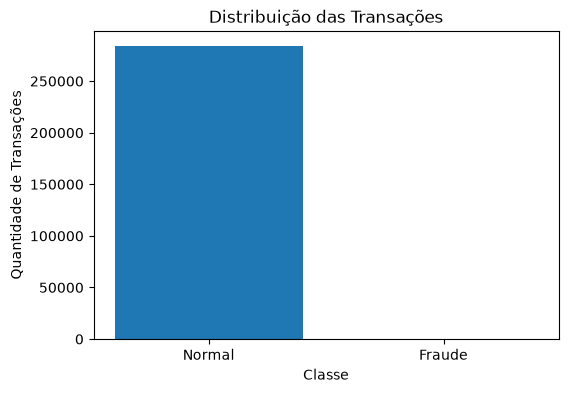

In [9]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    ["Normal", "Fraude"],
    [class_counts[0], class_counts[1]]
)

plt.title("Distribuição das Transações")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Transações")

plt.show()

### Conclusão sobre o desbalanceamento

A análise da variável `Class` mostrou um forte desbalanceamento entre as classes.

O dataset possui 284.315 transações classificadas como normais, representando aproximadamente 99,83% dos dados.

Por outro lado, existem apenas 492 transações fraudulentas, representando aproximadamente 0,17% do dataset.

Esse desbalanceamento representa um desafio para os modelos de Machine Learning, pois uma métrica como Accuracy pode apresentar resultados aparentemente altos mesmo que o modelo tenha baixa capacidade de identificar transações fraudulentas.

Por esse motivo, neste projeto serão utilizadas métricas como Precision, Recall, F1-score e ROC-AUC para avaliar o desempenho dos modelos.

## 5. Preparação dos Dados e Feature Engineering

Nesta etapa, os dados serão preparados para o treinamento dos modelos de Machine Learning.

Será criada uma nova variável baseada no valor das transações e, posteriormente, os dados serão separados entre variáveis de entrada e variável alvo.

### Transformação da variável Amount

A variável `Amount` apresenta valores com grande variação entre as transações.

Para reduzir o impacto de valores extremamente altos, foi criada uma nova variável chamada `Amount_log`, utilizando uma transformação logarítmica.

A transformação `log1p` aplica o cálculo `log(1 + x)`, permitindo também o tratamento de valores iguais a zero.

In [10]:
# Criação da variável transformada
df["Amount_log"] = np.log1p(df["Amount"])

df[["Amount", "Amount_log"]].head()


,Amount,Amount_log
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


### Separação das variáveis

Para o treinamento dos modelos, o dataset será dividido entre:

- `X`: variáveis de entrada utilizadas pelo modelo para realizar previsões.
- `y`: variável alvo que representa se uma transação é normal ou fraudulenta.

A coluna `Amount` original será removida das variáveis de entrada, sendo utilizada em seu lugar a variável transformada `Amount_log`.

In [11]:
X = df.drop(columns=["Class", "Amount"])
y = df["Class"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (284807, 30)
Formato de y: (284807,)


## 6. Divisão dos Dados em Treino e Teste

Os dados serão divididos em conjuntos de treinamento e teste.

O conjunto de treinamento será utilizado para treinar os modelos de Machine Learning, enquanto o conjunto de teste será reservado para avaliar o desempenho do modelo em dados que não foram utilizados durante o treinamento.

Como o dataset apresenta um forte desbalanceamento entre as classes, será utilizado o parâmetro `stratify=y` para preservar a proporção entre transações normais e fraudulentas nos conjuntos de treino e teste.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [13]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (199364, 30)
X_test: (85443, 30)
y_train: (199364,)
y_test: (85443,)


In [14]:
print("Distribuição no treino:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True) * 100)


Distribuição no treino:
Class
0    99.827451
1     0.172549
Name: proportion, dtype: float64

Distribuição no teste:
Class
0    99.826785
1     0.173215
Name: proportion, dtype: float64


### Resultado da divisão

O dataset foi dividido em 70% para treinamento e 30% para teste.

O conjunto de treinamento possui 199.364 transações, enquanto o conjunto de teste possui 85.443 transações.

O parâmetro `stratify=y` preservou a proporção entre transações normais e fraudulentas nos dois conjuntos.

Dessa forma, tanto os dados de treinamento quanto os dados de teste mantiveram o forte desbalanceamento presente no dataset original.

## 7. Escalonamento dos Dados

Algoritmos como a Regressão Logística podem ser influenciados por diferenças na escala das variáveis.

Por esse motivo, será utilizado o `StandardScaler` para padronizar as variáveis de entrada.

Para evitar data leakage, o processo de ajuste do escalonador será realizado apenas com os dados de treinamento. Os dados de teste serão transformados utilizando o mesmo escalonador ajustado no conjunto de treinamento.

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
print("Formato do treino escalonado:", X_train_scaled.shape)
print("Formato do teste escalonado:", X_test_scaled.shape)

Formato do treino escalonado: (199364, 30)
Formato do teste escalonado: (85443, 30)


## 8. Modelo Base: Regressão Logística

Nesta etapa, será treinado um modelo de Regressão Logística para servir como modelo base do projeto.

O objetivo é avaliar a capacidade inicial do algoritmo em identificar transações fraudulentas utilizando os dados originais, que apresentam um forte desbalanceamento entre as classes.

In [17]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [18]:
y_pred = logistic_model.predict(X_test_scaled)

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.62      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



### Avaliação inicial do modelo

A Regressão Logística apresentou bom desempenho na identificação de transações normais.

Para a classe de fraude, o modelo obteve aproximadamente 86% de Precision, indicando que a maioria das transações classificadas como fraudulentas realmente correspondia a uma fraude.

O Recall obtido foi de aproximadamente 62%, indicando que o modelo conseguiu identificar parte significativa das fraudes presentes no conjunto de teste, mas ainda deixou algumas transações fraudulentas sem detecção.

Como o objetivo de um sistema de detecção de fraudes é identificar o maior número possível de transações fraudulentas, o Recall será uma métrica importante nas próximas etapas do projeto.

Além disso, devido ao forte desbalanceamento das classes, a Accuracy isoladamente não será utilizada como principal métrica de avaliação.

## 9. Matriz de Confusão

A matriz de confusão será utilizada para analisar com mais detalhes os acertos e erros do modelo.

Ela permite identificar:

- Transações normais classificadas corretamente
- Transações normais classificadas incorretamente como fraude
- Fraudes que não foram detectadas
- Fraudes identificadas corretamente

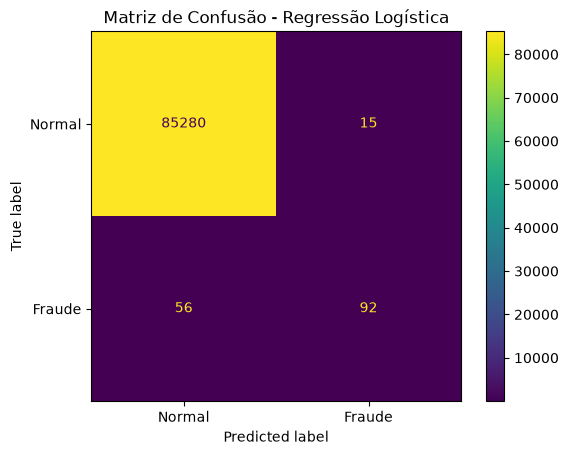

In [20]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraude"]
)

disp.plot()

plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

### Interpretação da Matriz de Confusão

A matriz de confusão mostrou que o modelo classificou corretamente 85.280 transações normais.

Além disso, apenas 15 transações normais foram incorretamente classificadas como fraudulentas, representando os falsos positivos.

Em relação às transações fraudulentas, o modelo conseguiu identificar corretamente 92 fraudes.

No entanto, 56 transações fraudulentas foram classificadas como normais, representando os falsos negativos.

Em um sistema de detecção de fraudes, os falsos negativos são especialmente importantes, pois representam transações fraudulentas que não foram detectadas pelo modelo.

Esses resultados reforçam a necessidade de explorar técnicas para melhorar a capacidade de identificação das fraudes nas próximas etapas do projeto.

## 10. Curva ROC e ROC-AUC

Além das métricas de classificação, será utilizada a curva ROC para avaliar a capacidade do modelo de diferenciar transações normais e fraudulentas.

A métrica ROC-AUC permite medir a capacidade geral do modelo de distinguir entre as duas classes.

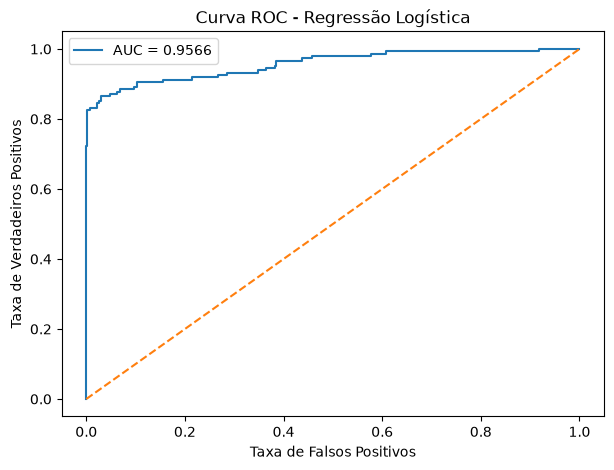

ROC-AUC: 0.9566


In [21]:
y_probs = logistic_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

roc_auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - Regressão Logística")
plt.legend()

plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

### Interpretação da Curva ROC e ROC-AUC

O modelo de Regressão Logística obteve um ROC-AUC de aproximadamente 0,956.

Esse resultado indica que o modelo possui uma excelente capacidade de distinguir transações normais de transações fraudulentas.

Entretanto, apesar do alto valor de ROC-AUC, o Recall da classe de fraude ainda pode ser melhorado.

Isso ocorre porque a classificação padrão utiliza um threshold de 0,5 para transformar as probabilidades previstas em classes.

Nas próximas etapas, será analisado o impacto da utilização de diferentes thresholds para verificar se é possível aumentar a quantidade de fraudes detectadas.

## 11. Ajuste do Threshold de Decisão

Por padrão, modelos de classificação binária utilizam um threshold de 0,5 para definir a classe prevista.

Neste projeto, serão testados diferentes thresholds para analisar o impacto na capacidade de detecção de transações fraudulentas.

O objetivo é avaliar o equilíbrio entre a identificação de fraudes e a quantidade de falsos positivos gerados pelo modelo.

In [22]:
y_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [23]:
threshold = 0.3

y_pred_custom = (y_proba >= threshold).astype(int)


In [24]:
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.80      0.66      0.72       148

    accuracy                           1.00     85443
   macro avg       0.90      0.83      0.86     85443
weighted avg       1.00      1.00      1.00     85443



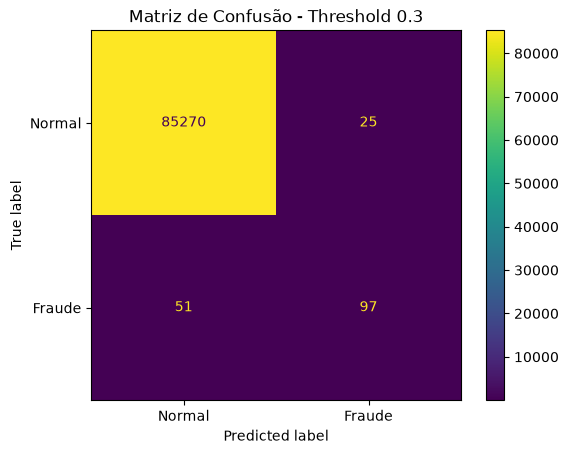

In [25]:
cm_custom = confusion_matrix(y_test, y_pred_custom)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_custom,
    display_labels=["Normal", "Fraude"]
)

disp.plot()

plt.title("Matriz de Confusão - Threshold 0.3")
plt.show()

### Comparação com Threshold Personalizado

O threshold padrão de 0,5 foi reduzido para 0,3 com o objetivo de aumentar a capacidade do modelo de identificar transações fraudulentas.

Com o threshold de 0,3, o Recall da classe de fraude aumentou de aproximadamente 62% para 66%.

Entretanto, a Precision foi reduzida de aproximadamente 86% para 80%.

Esse resultado demonstra um trade-off importante em sistemas de detecção de fraude: aumentar a sensibilidade do modelo pode permitir a identificação de mais fraudes, mas também pode aumentar a quantidade de transações normais classificadas como suspeitas.

A escolha do threshold ideal depende do contexto e dos custos associados aos falsos negativos e falsos positivos.

## 12. Comparação de Diferentes Thresholds

Para analisar o impacto do threshold na detecção de fraudes, serão testados diferentes valores de decisão.

O objetivo é observar como a alteração do threshold influencia métricas como Precision, Recall e F1-score, permitindo analisar o equilíbrio entre a capacidade de detectar fraudes e a geração de falsos positivos.

In [26]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

resultados = []

for threshold in thresholds:

    y_pred_threshold = (y_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    resultados.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

df_thresholds = pd.DataFrame(resultados)

df_thresholds

,Threshold,Precision,Recall,F1-score
0,0.1,0.751773,0.716216,0.733564
1,0.2,0.786260,0.695946,0.738351
2,0.3,0.795082,0.655405,0.718519
3,0.4,0.842105,0.648649,0.732824
4,0.5,0.859813,0.621622,0.721569


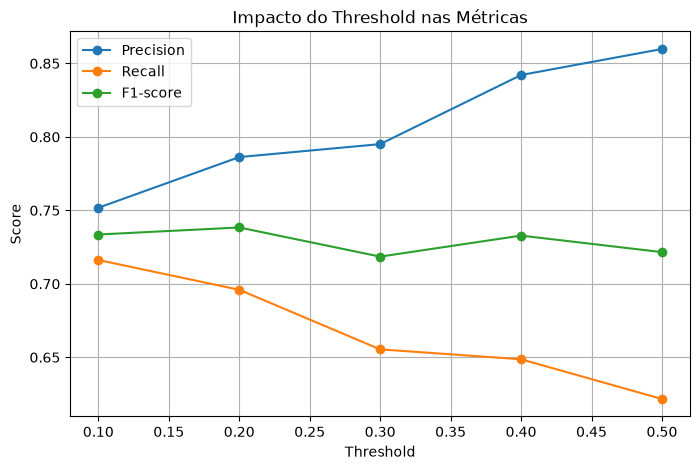

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_thresholds["Threshold"],
    df_thresholds["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    df_thresholds["Threshold"],
    df_thresholds["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    df_thresholds["Threshold"],
    df_thresholds["F1-score"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Impacto do Threshold nas Métricas")
plt.legend()
plt.grid()

plt.show()

### Análise dos Diferentes Thresholds

Foram testados diferentes valores de threshold para analisar o impacto na classificação das transações fraudulentas.

Os resultados mostraram que a redução do threshold aumenta a capacidade do modelo de identificar fraudes, representada pelo Recall.

Entretanto, essa alteração também reduz a Precision, aumentando a possibilidade de transações normais serem classificadas como fraudulentas.

O threshold de 0,1 apresentou o maior Recall, identificando aproximadamente 71,6% das fraudes.

Por outro lado, o threshold de 0,2 apresentou o maior F1-score, representando o melhor equilíbrio entre Precision e Recall entre os valores analisados.

Dessa forma, a escolha do threshold depende do objetivo do sistema de detecção de fraudes e do impacto associado aos falsos positivos e falsos negativos.

## 13. Comparação com Random Forest

Para comparar o desempenho da Regressão Logística, será utilizado um segundo algoritmo de Machine Learning: o Random Forest.

O objetivo é analisar se um modelo baseado em árvores de decisão consegue melhorar a identificação de transações fraudulentas.

A comparação será realizada utilizando principalmente as métricas Precision, Recall e F1-score da classe de fraude.

In [28]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [29]:
y_pred_rf = random_forest_model.predict(X_test)

In [30]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.96      0.76      0.85       148

    accuracy                           1.00     85443
   macro avg       0.98      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443



### Avaliação do Random Forest

O modelo Random Forest apresentou um desempenho superior ao modelo de Regressão Logística na identificação de transações fraudulentas.

Para a classe de fraude, o modelo obteve aproximadamente 96% de Precision, 76% de Recall e 85% de F1-score.

O resultado indica que o Random Forest conseguiu identificar uma quantidade maior de fraudes e, ao mesmo tempo, manteve uma alta precisão nas classificações realizadas.

Em comparação com a Regressão Logística, o Random Forest apresentou melhor desempenho nas principais métricas analisadas para a classe minoritária.

Dessa forma, entre os modelos avaliados até esta etapa, o Random Forest apresentou o melhor desempenho para a detecção de transações fraudulentas.

### Matriz de Confusão do Random Forest

A matriz de confusão será utilizada para analisar detalhadamente a quantidade de transações classificadas corretamente e incorretamente pelo modelo Random Forest.

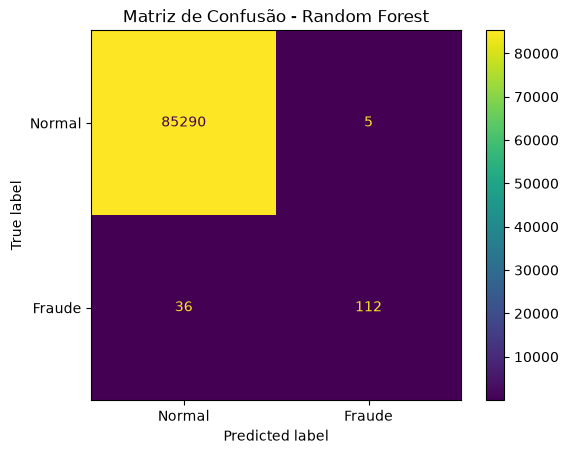

In [31]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normal", "Fraude"]
)

disp.plot()

plt.title("Matriz de Confusão - Random Forest")
plt.show()

### Análise da Matriz de Confusão

A matriz de confusão do Random Forest mostrou que o modelo identificou corretamente 112 das 148 transações fraudulentas presentes no conjunto de teste.

Apenas 36 transações fraudulentas foram classificadas incorretamente como normais, representando os falsos negativos.

Além disso, apenas 5 transações normais foram classificadas incorretamente como fraude.

Em comparação com a Regressão Logística, o Random Forest apresentou uma redução tanto na quantidade de fraudes não detectadas quanto na quantidade de falsos positivos.

Esse resultado reforça que, entre os modelos avaliados, o Random Forest apresentou o melhor desempenho para o problema de detecção de fraudes.

## 14. Comparação Final dos Modelos

Foram avaliadas duas abordagens diferentes para o problema de detecção de fraudes: Regressão Logística e Random Forest.

Além disso, foram testados diferentes valores de threshold na Regressão Logística para analisar o impacto da decisão de classificação nas métricas do modelo.

O Random Forest apresentou o melhor desempenho geral, obtendo os maiores valores de Precision, Recall e F1-score para a identificação de transações fraudulentas.

A Regressão Logística com threshold padrão apresentou maior Precision, mas identificou uma quantidade menor de fraudes.

A redução do threshold da Regressão Logística aumentou o Recall, demonstrando que o ajuste do threshold pode ser utilizado para adaptar o comportamento do modelo de acordo com os objetivos do sistema.

Entre todos os modelos e configurações avaliados, o Random Forest apresentou o melhor equilíbrio entre a capacidade de identificar fraudes e a precisão das classificações.

In [32]:
comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "Regressão Logística (0.5)",
        "Regressão Logística (0.2)",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, (y_proba >= 0.2).astype(int)),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, (y_proba >= 0.2).astype(int)),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, (y_proba >= 0.2).astype(int)),
        f1_score(y_test, y_pred_rf)
    ]
})

comparacao_modelos

,Modelo,Precision,Recall,F1-score
0,Regressão Logística (0.5),0.859813,0.621622,0.721569
1,Regressão Logística (0.2),0.786260,0.695946,0.738351
2,Random Forest,0.957265,0.756757,0.845283


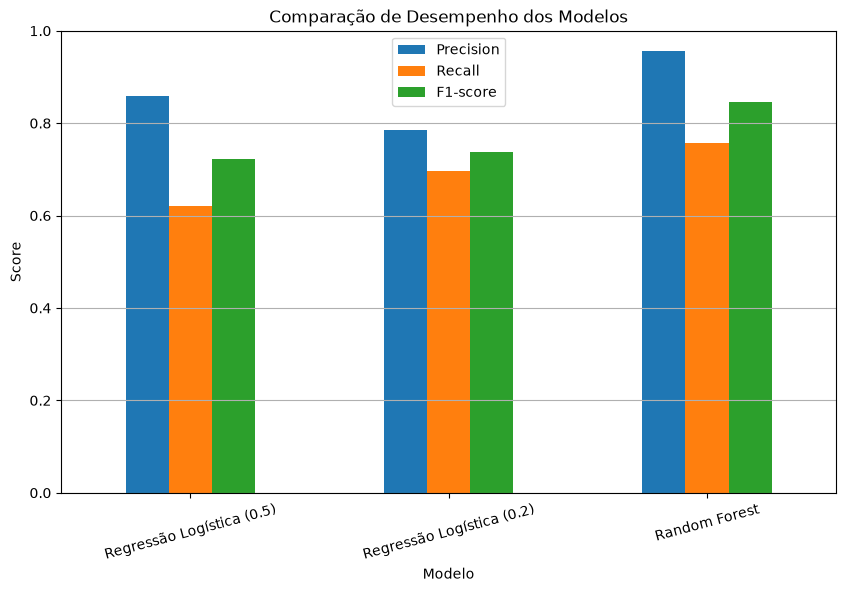

In [33]:
comparacao_modelos.plot(
    x="Modelo",
    y=["Precision", "Recall", "F1-score"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparação de Desempenho dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.grid(axis="y")

plt.show()

## 15. Classificação de Nível de Risco

Após identificar o Random Forest como o modelo com melhor desempenho entre os modelos avaliados, foi implementada uma camada adicional de classificação de risco.

Em vez de apresentar apenas a previsão binária de fraude ou não fraude, o sistema utiliza a probabilidade prevista pelo modelo para categorizar cada transação em diferentes níveis de risco.

Os níveis definidos foram:

- 🟢 **Baixo risco:** probabilidade de fraude inferior a 20%.
- 🟡 **Médio risco:** probabilidade de fraude entre 20% e 60%.
- 🔴 **Alto risco:** probabilidade de fraude igual ou superior a 60%.

Essa classificação tem como objetivo simular um sistema de apoio à decisão, permitindo que transações com diferentes níveis de suspeita recebam tratamentos distintos.

In [34]:
y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [35]:
y_proba_rf[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [36]:
np.sort(y_proba_rf)[-10:]

array([0.99, 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ])

In [37]:
pd.Series(y_proba_rf).describe()

count    85443.000000
mean         0.001669
std          0.033200
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
dtype: float64

In [38]:
def classificar_risco(probabilidade):
    
    if probabilidade < 0.20:
        return "Baixo risco"
    
    elif probabilidade < 0.60:
        return "Médio risco"
    
    else:
        return "Alto risco"

### Distribuição dos Níveis de Risco

Após classificar as transações de acordo com a probabilidade estimada de fraude, será analisada a quantidade de transações presentes em cada nível de risco.

Essa análise permite observar como o modelo distribui as transações entre os níveis de baixo, médio e alto risco.

In [39]:
resultado_risco = pd.DataFrame({
    "Probabilidade de Fraude": y_proba_rf,
    "Classe Real": y_test.values
})

resultado_risco["Nível de Risco"] = resultado_risco[
    "Probabilidade de Fraude"
].apply(classificar_risco)

resultado_risco.head(10)

,Probabilidade de Fraude,Classe Real,Nível de Risco
0,0.0,0,Baixo risco
1,0.0,0,Baixo risco
2,0.0,0,Baixo risco
3,0.0,0,Baixo risco
4,0.0,0,Baixo risco
5,0.0,0,Baixo risco
6,0.0,0,Baixo risco
7,0.0,0,Baixo risco
8,0.0,0,Baixo risco
9,0.0,0,Baixo risco


In [40]:
resultado_risco.sort_values(
    by="Probabilidade de Fraude",
    ascending=False
).head(10)

,Probabilidade de Fraude,Classe Real,Nível de Risco
34142,1.00,1,Alto risco
21538,1.00,1,Alto risco
19197,1.00,1,Alto risco
61477,1.00,1,Alto risco
355,1.00,1,Alto risco
5938,1.00,1,Alto risco
80285,1.00,1,Alto risco
32282,1.00,1,Alto risco
23598,1.00,1,Alto risco
9371,0.99,1,Alto risco


In [41]:
resultado_risco["Nível de Risco"].value_counts()

Nível de Risco
Baixo risco    85291
Alto risco       107
Médio risco       45
Name: count, dtype: int64

### Visualização da Distribuição dos Níveis de Risco

A visualização abaixo apresenta a quantidade de transações classificadas em cada nível de risco pelo sistema.

Como o conjunto de dados é altamente desbalanceado e a maioria das transações é legítima, espera-se que a maior parte seja classificada como de baixo risco.

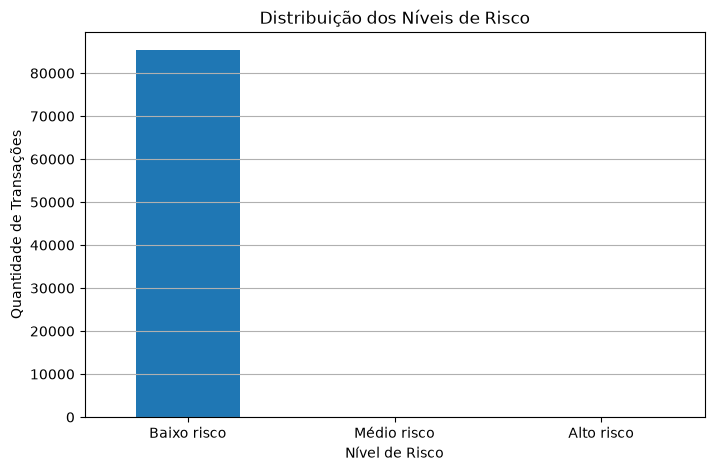

In [42]:
ordem_risco = ["Baixo risco", "Médio risco", "Alto risco"]

resultado_risco["Nível de Risco"].value_counts().reindex(ordem_risco).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribuição dos Níveis de Risco")
plt.xlabel("Nível de Risco")
plt.ylabel("Quantidade de Transações")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

## Distribuição Percentual dos Níveis de Risco

Além da quantidade absoluta de transações, a análise percentual permite observar
melhor a proporção de cada nível de risco, considerando o forte desbalanceamento
existente na base de dados.

In [43]:
risk_percentage = (
    resultado_risco["Nível de Risco"]
    .value_counts(normalize=True)
    .mul(100)
)

print(risk_percentage)

Nível de Risco
Baixo risco    99.822104
Alto risco      0.125230
Médio risco     0.052667
Name: proportion, dtype: float64


# 16. Conclusão

Este projeto teve como objetivo desenvolver e avaliar modelos de Machine Learning para a detecção de fraudes em transações financeiras.

Durante a análise exploratória, foi identificado um forte desbalanceamento entre as classes. Aproximadamente 99,83% das transações pertencem à classe normal, enquanto apenas cerca de 0,17% representam fraudes. Por esse motivo, a métrica de accuracy isoladamente não é suficiente para avaliar o desempenho dos modelos.

Inicialmente, foi utilizado o modelo de Regressão Logística como baseline. Também foram realizados testes com diferentes thresholds de classificação, permitindo analisar o equilíbrio entre precision e recall.

Posteriormente, foi utilizado o modelo Random Forest, que apresentou melhor desempenho na identificação das transações fraudulentas. Nos resultados obtidos, o modelo alcançou aproximadamente:

- Precision: 95,7%
- Recall: 75,7%
- F1-score: 84,5%

Além da classificação tradicional entre fraude e não fraude, foi implementada uma camada adicional de classificação de risco baseada na probabilidade estimada pelo modelo.

As transações foram classificadas em:

- 🟢 Baixo risco
- 🟡 Médio risco
- 🔴 Alto risco

Essa abordagem permite transformar as previsões do modelo em informações mais interpretáveis e que poderiam ser utilizadas como apoio à tomada de decisão em um cenário real.

Apesar dos resultados positivos, o projeto possui algumas limitações. O conjunto de dados utilizado é altamente desbalanceado e representa um cenário específico. Como possíveis melhorias futuras, podem ser exploradas técnicas de balanceamento como SMOTE, otimização de hiperparâmetros e outros algoritmos de Machine Learning.

De forma geral, o projeto demonstrou a importância da escolha correta das métricas em problemas de classificação desbalanceada e mostrou como diferentes modelos e thresholds podem impactar a capacidade de detectar transações fraudulentas.